In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Data Analyst\Project\data_cleaning_with_pandas\Uncleaned_practice.csv")

df.head(10)

,Employee ID,Employee Name,Employee Position,Salary,Age,Gender,Department,Hire Date
0,178,Christopher Reilly,employee,99280.0,62.0,Male,Accounts,2020-07-28
1,2,Jennifer Newton,employee,66717.0,NaN,Male,NaN,2018-11-04
2,42,Dakota Khan,Administrator,87759.0,56.0,Female,Accounts,2023-03-30
3,177,Nancy Long,Techies,75973.0,59.0,Male,Manegement,2018-06-27
4,55,Jeffrey Miller,Techies,67856.0,45.0,Male,Administration,2022-03-19
5,46,Elizabeth Tanner,Manager,89041.0,65.0,Male,Accounts,2019-05-15
6,5,Shawn Harrington,Techies,74446.0,NaN,Female,Accounts,2022-12-05
7,44,Matthew Knapp,employee,72556.0,42.0,Female,Sales,2022-12-10
8,83,Jessica Shepherd,employee,10.0,32.0,Female,Accounts,2019-10-25
9,111,Anna Logan,Manager,65501.0,57.0,Male,Manegement,2017-11-07


In [3]:
df.shape

(208, 8)

In [4]:
print("The total number of rows are :", df.shape[0])
print("The total number of columns are :", df.shape[1])


The total number of rows are : 208
The total number of columns are : 8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee ID        208 non-null    int64  
 1   Employee Name      208 non-null    object 
 2   Employee Position  208 non-null    object 
 3   Salary             205 non-null    object 
 4   Age                206 non-null    float64
 5   Gender             207 non-null    object 
 6   Department         205 non-null    object 
 7   Hire Date          207 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 13.1+ KB


In [6]:
missing_values = df.isnull().sum()

print(missing_values)

Employee ID          0
Employee Name        0
Employee Position    0
Salary               3
Age                  2
Gender               1
Department           3
Hire Date            1
dtype: int64


In [7]:
df["Salary"]  = df["Salary"].replace("Sixty Thousand",60000)

In [8]:
# Converting object(text) to numeric
 
df["Salary"] = pd.to_numeric(df["Salary"]) 

In [9]:
# Fix the outliers

df.loc[(df["Salary"] < 20000) | (df["Salary"] > 100000),"Salary"] = np.nan

In [10]:
# Impute the missing Values with the salary columns

df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

In [11]:
# Fix the outliers in Age columns

df.loc[(df["Age"] < 18) | (df["Age"] > 60),"Age"] = np.nan


# Impute the missing Values with the mean of Age columns

df["Age"] = df["Age"].fillna(df["Age"].mean())

In [12]:
# Impute the missing Values with the mode for Gender columns

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [13]:
# Impute the missing Values with the mode for Department columns

df["Department"] = df["Department"].fillna(df["Department"].mode()[0])

In [14]:
# Replacing invalid date which was throwing error during the date time conversion   

df["Hire Date"] = pd.to_datetime(df["Hire Date"],errors="coerce").fillna("Not Known")

In [15]:
df["Department"].value_counts()

Department
Manegement         56
Sales              47
Administration     41
Accounts           34
Human_Resources    29
Sales&Marketing     1
Name: count, dtype: int64

In [16]:
# Replace Management spelling

df["Department"] = df["Department"].replace("Manegement","Management")

In [17]:
df["Gender"] = df["Gender"].replace("Unknown","Others")
df["Gender"] = df["Gender"].replace("Not Disclosed","Others")

In [18]:
df["Gender"].value_counts()

Gender
Female    108
Male       98
Others      2
Name: count, dtype: int64

In [19]:
df["Employee Position"].value_counts()

Employee Position
employee         56
Techies          52
Manager          50
Administrator    49
Tech@ies          1
Name: count, dtype: int64

In [20]:
df["Employee Position"] = df["Employee Position"].replace("Tech@ies","Techies")

In [21]:
df.head(20)

,Employee ID,Employee Name,Employee Position,Salary,Age,Gender,Department,Hire Date
0,178,Christopher Reilly,employee,99280.000000,44.48,Male,Accounts,2020-07-28 00:00:00
1,2,Jennifer Newton,employee,66717.000000,44.48,Male,Management,2018-11-04 00:00:00
2,42,Dakota Khan,Administrator,87759.000000,56.00,Female,Accounts,2023-03-30 00:00:00
3,177,Nancy Long,Techies,75973.000000,59.00,Male,Management,2018-06-27 00:00:00
4,55,Jeffrey Miller,Techies,67856.000000,45.00,Male,Administration,2022-03-19 00:00:00
5,46,Elizabeth Tanner,Manager,89041.000000,44.48,Male,Accounts,2019-05-15 00:00:00
6,5,Shawn Harrington,Techies,74446.000000,44.48,Female,Accounts,2022-12-05 00:00:00
7,44,Matthew Knapp,employee,72556.000000,42.00,Female,Sales,2022-12-10 00:00:00
8,83,Jessica Shepherd,employee,80701.341584,32.00,Female,Accounts,2019-10-25 00:00:00
9,111,Anna Logan,Manager,65501.000000,57.00,Male,Management,2017-11-07 00:00:00


In [22]:
df["Salary"] = df["Salary"].astype(int)

In [23]:
df["Age"] = df["Age"].astype(int)


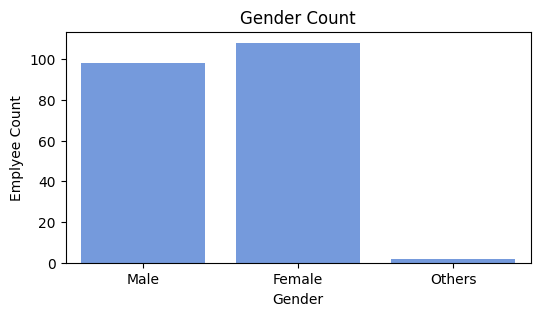

In [24]:
# Visualise the count of Genders

plt.figure(figsize=(6,3))
sns.countplot(x="Gender",data = df,color="cornflowerblue")
plt.title("Gender Count")
plt.ylabel("Emplyee Count")
plt.show()

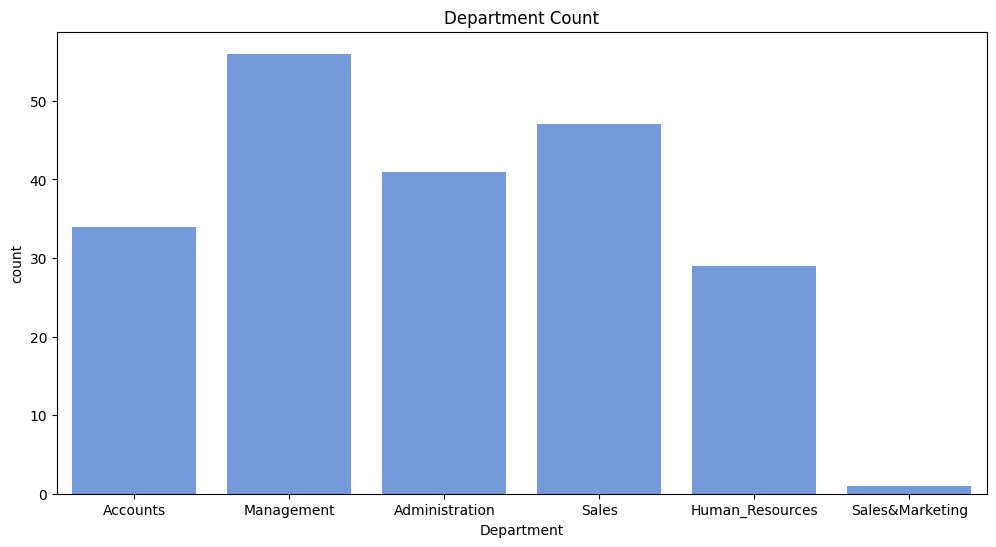

In [25]:
# How many emplyee are there in each departments

plt.figure(figsize=(12,6))
sns.countplot(x= "Department",data = df,color="cornflowerblue")
plt.title("Department Count")
plt.show()

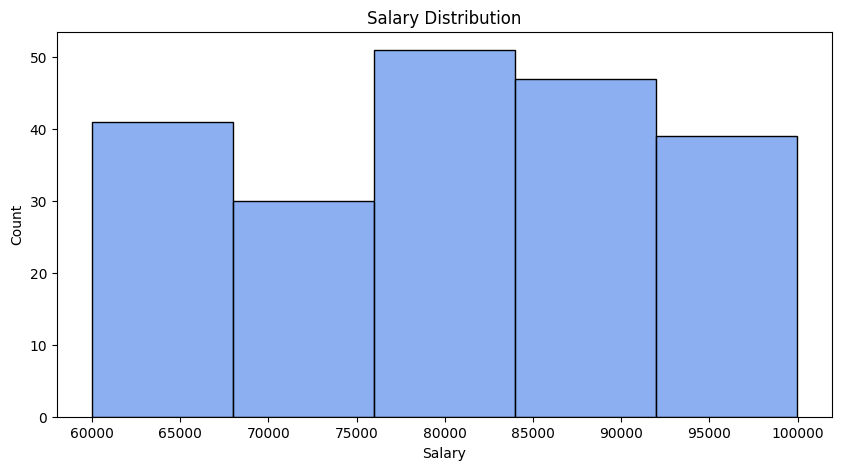

In [26]:
# Distibution of Salary

plt.figure(figsize=(10,5))
sns.histplot(x="Salary",data = df,color="cornflowerblue",bins=5)
plt.title("Salary Distribution")
plt.show()

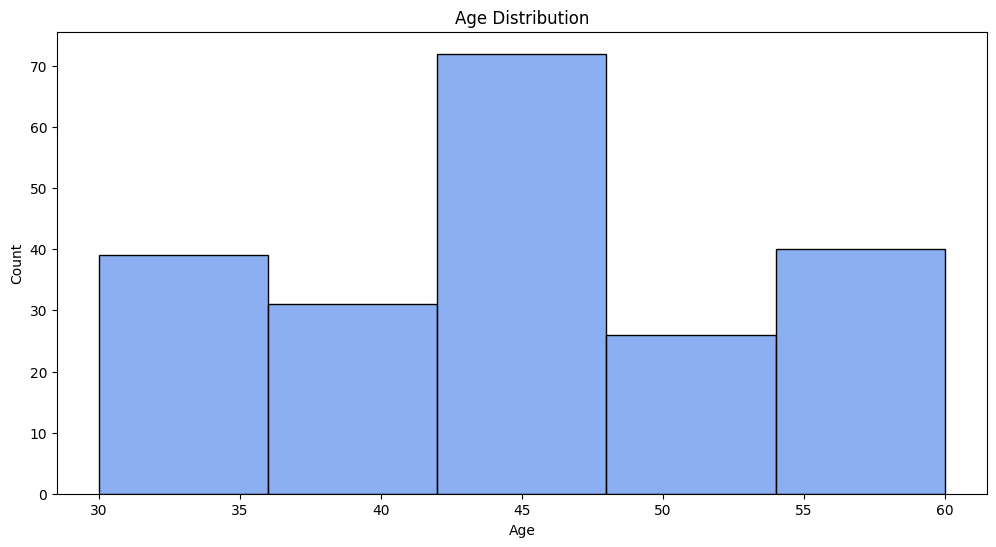

In [27]:
# Visualise the Age Distribution of the employee

plt.figure(figsize=(12,6))
sns.histplot(x="Age",data = df,color="cornflowerblue",bins=5)
plt.title("Age Distribution")
plt.show()

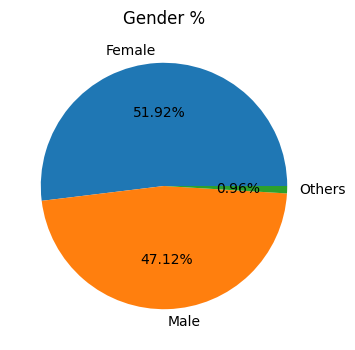

In [28]:
# Gender Count through a pie chart

pie_chart = df["Gender"].value_counts()
plt.figure(figsize=(8,4))
plt.pie(pie_chart,labels = pie_chart.index,autopct="%.2f%%")
plt.title('Gender %')
plt.show()


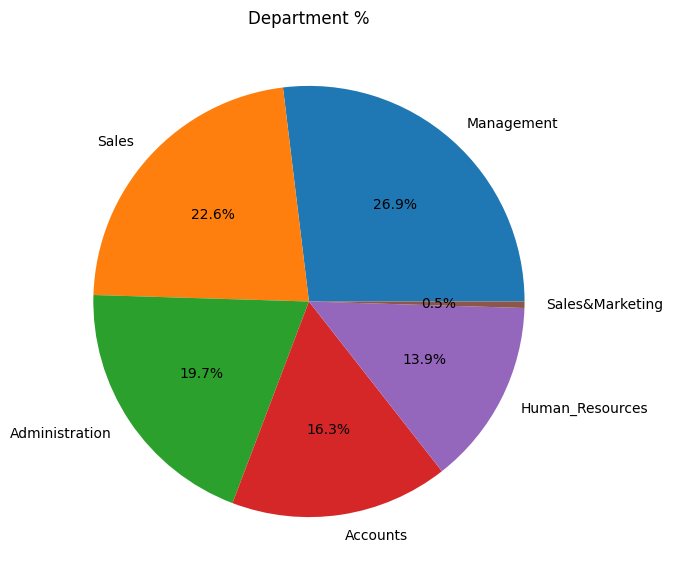

In [29]:
employee_chart = df["Department"].value_counts()
plt.figure(figsize=(10,7))
plt.pie(employee_chart,labels = employee_chart.index,autopct="%.1f%%")
plt.title('Department %')
plt.show()

In [30]:
#df.to_csv("cleaned_data.csv",index=False)